In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib as mpl
from matplotlib import font_manager

# Source Sans 3 (la stessa famiglia usata di default in PowerPoint) per
# tutti i grafici del notebook: risultato piu' leggibile e coerente con
# le slide/il report in cui questi grafici finiranno.
for _f in ["SourceSans3-Regular.ttf", "SourceSans3-SemiBold.ttf",
           "SourceSans3-Bold.ttf", "SourceSans3-Italic.ttf"]:
    font_manager.fontManager.addfont(f"/home/alice/.fonts/{_f}")

mpl.rcParams.update({
    "font.family": "Source Sans 3",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "axes.labelcolor": "#0b0b0b",
    "axes.edgecolor": "#c3c2b7",
    "axes.linewidth": 1.0,
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
})

# Palette categorica fissa: ogni massa mantiene sempre lo stesso colore,
# in tutti i grafici del notebook (il colore codifica l'identita').
COLORI_MASSE = {
    "m_jj":   "#2a78d6",
    "m_jjj":  "#eb6834",
    "m_lv":   "#1baf7a",
    "m_jlv":  "#eda100",
    "m_bb":   "#e87ba4",
    "m_wbb":  "#008300",
    "m_wwbb": "#4a3aa7",
}
ETICHETTE_MASSE = {
    "m_jj":   r"$m_{jj}$",
    "m_jjj":  r"$m_{jjj}$",
    "m_lv":   r"$m_{\ell\nu}$",
    "m_jlv":  r"$m_{j\ell\nu}$",
    "m_bb":   r"$m_{bb}$",
    "m_wbb":  r"$m_{Wbb}$",
    "m_wwbb": r"$m_{WWbb}$",
}
INCHIOSTRO_SECONDARIO = "#52514e"
INCHIOSTRO_MUTO = "#898781"

# Probing lineare

In [3]:
with open("../results/riproduzione/probing_deep_low_seme0.json") as f:
    p2014 = json.load(f)
with open("../results/moderno/probing_deep_low_seme0.json") as f:
    pmod = json.load(f)

In [4]:
masse = p2014["masse"]
r2 = p2014["r2"]   # dizionario: "input", "casuale_stratoK", "stratoK"

In [5]:
def matrice(p, prefisso="strato"):
    n = p["n_strati"]
    return np.array([p["r2"][f"{prefisso}{k}"] for k in range(1, n+1)])

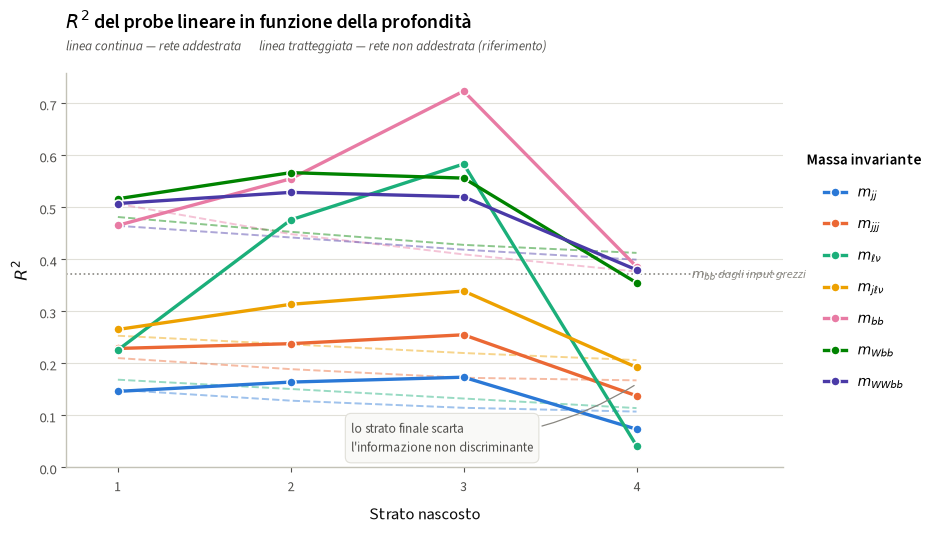

In [6]:
M = matrice(pmod)                    # (4, 7)
C = matrice(pmod, "casuale_strato")
inp = np.array(pmod["r2"]["input"])
strati = np.arange(1, 5)

fig, ax = plt.subplots(figsize=(9.5, 5.5))

for j, nome in enumerate(masse):
    colore = COLORI_MASSE[nome]
    ax.plot(strati, M[:, j], "-", marker="o", markersize=6.5,
            markerfacecolor=colore, markeredgecolor="white", markeredgewidth=1.1,
            color=colore, linewidth=2.4, zorder=3, label=ETICHETTE_MASSE[nome])
    ax.plot(strati, C[:, j], "--", color=colore, alpha=0.45, linewidth=1.4,
            zorder=2)

ax.axhline(y=inp[4], color=INCHIOSTRO_MUTO, ls=":", lw=1.2, zorder=1)
ax.text(4.32, inp[4], r"$m_{bb}$ dagli input grezzi", va="center", ha="left",
        fontsize=9, color=INCHIOSTRO_MUTO, style="italic")

ax.annotate(
    "lo strato finale scarta\nl'informazione non discriminante",
    xy=(4, 0.16), xytext=(2.35, 0.03),
    fontsize=9.5, color=INCHIOSTRO_SECONDARIO, ha="left",
    arrowprops=dict(arrowstyle="-", color=INCHIOSTRO_MUTO, lw=0.9,
                     connectionstyle="arc3,rad=0.15"),
    bbox=dict(boxstyle="round,pad=0.45", fc="#f9f9f7", ec="#e1e0d9", lw=0.8),
)

ax.text(0.0, 1.045,
        "linea continua — rete addestrata      linea tratteggiata — rete non addestrata (riferimento)",
        transform=ax.transAxes, va="bottom", ha="left",
        fontsize=9.5, color=INCHIOSTRO_SECONDARIO, style="italic")

ax.set_title("$R^2$ del probe lineare in funzione della profondità",
             loc="left", pad=32)
ax.set_xlabel("Strato nascosto")
ax.set_ylabel("$R^2$")
ax.set_xticks(strati)
ax.set_xlim(0.7, 4.85)
ax.set_ylim(0, None)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", zorder=0)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

leg = ax.legend(
    title="Massa invariante",
    loc="center left", bbox_to_anchor=(1.015, 0.5),
    handlelength=1.6, labelspacing=0.85, frameon=False,
)
leg.get_title().set_fontweight("semibold")
leg.get_title().set_ha("left")

fig.tight_layout()

### $R^2$ del probe lineare in funzione della profondità

Ogni linea continua è una massa invariante; la tratteggiata dello stesso
colore è il riferimento ottenuto con una rete della stessa forma ma **non
addestrata**. Il confronto va fatto verticalmente, fra continua e
tratteggiata allo stesso strato: la differenza è ciò che l'addestramento
ha aggiunto, al netto della semplice proiezione in 300 dimensioni.

Si leggono tre cose.

**Le tratteggiate calano in modo monotono.** Una rete casuale non aggiunge
informazione: ogni strato ne perde un po', perché la ReLU azzera metà dei
valori. È il degrado di riferimento.

**Le continue salgono fino al terzo strato.** La rete costruisce
progressivamente quantità da cui le masse sono linearmente leggibili,
partendo da variabili grezze in cui non lo erano. Su $m_{bb}$ si passa da
$R^2 = 0.37$ sugli input a $0.72$ allo strato 3; su $m_{\ell\nu}$ da
$0.13$ a $0.58$. È la verifica diretta dell'affermazione del paper, che
era invece dedotta indirettamente dalle prestazioni.

**Al quarto strato tutte crollano**, in alcuni casi sotto il livello della
rete casuale. Lo strato immediatamente precedente all'uscita è ottimizzato
per comprimere l'evento in un singolo numero, la decisione segnale/fondo:
ciò che non serve a quella decisione viene scartato. Non è degrado
passivo — è eliminazione attiva, e infatti $m_{\ell\nu}$, che ha potere
discriminante nullo, è quella che viene scartata di più.

La rete quindi **costruisce** le masse nei primi strati e le **consuma**
nell'ultimo.

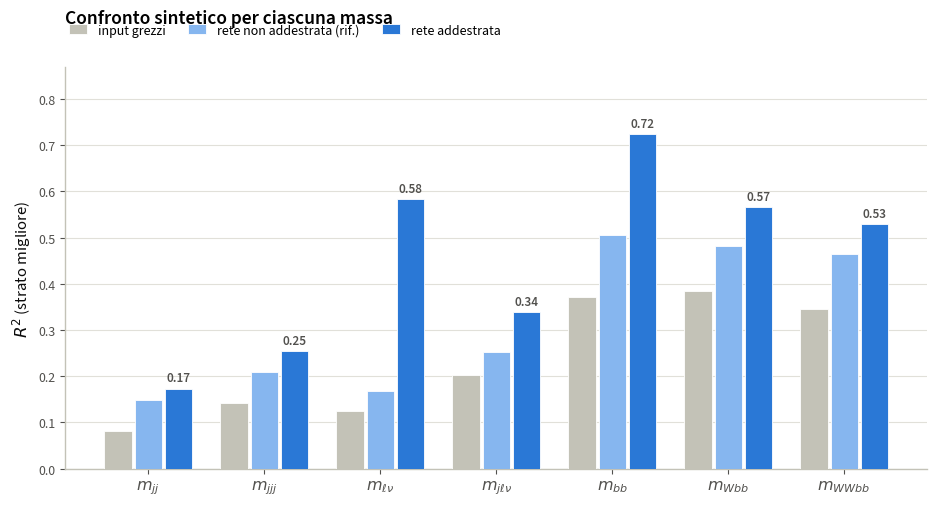

In [7]:
x = np.arange(len(masse))
w = 0.26
migliore = M.max(axis=0)          # strato migliore per ciascuna massa
migliore_c = C.max(axis=0)

fig, ax = plt.subplots(figsize=(9.5, 5.2))

bw = w * 0.9
b_input = ax.bar(x - w, inp, bw, label="input grezzi",
                  color="#c3c2b7", edgecolor="white", linewidth=0.6, zorder=3)
b_casuale = ax.bar(x, migliore_c, bw, label="rete non addestrata (rif.)",
                    color="#86b6ef", edgecolor="white", linewidth=0.6, zorder=3)
b_addestrata = ax.bar(x + w, migliore, bw, label="rete addestrata",
                       color="#2a78d6", edgecolor="white", linewidth=0.6, zorder=3)

ax.bar_label(b_addestrata, fmt="%.2f", padding=3, fontsize=9.5,
             color=INCHIOSTRO_SECONDARIO, fontweight="semibold")

ax.set_title("Confronto sintetico per ciascuna massa", loc="left", pad=32)
ax.set_ylabel("$R^2$ (strato migliore)")
ax.set_xticks(x)
ax.set_xticklabels([ETICHETTE_MASSE[m] for m in masse], fontsize=11.5)
ax.set_ylim(0, max(migliore.max(), migliore_c.max(), inp.max()) * 1.2)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", zorder=0)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.legend(loc="upper left", bbox_to_anchor=(-0.01, 1.14), ncol=3,
          handlelength=1.3, columnspacing=1.6, frameon=False)

fig.tight_layout()

### Confronto sintetico per ciascuna massa

Tre barre per massa: informazione linearmente estraibile dalle variabili
grezze in ingresso, dalla rete non addestrata, e dalla rete addestrata.
Per le ultime due si riporta il valore dello **strato migliore**, non
dell'ultimo.

La barra arancione è il riferimento indispensabile: una combinazione
lineare di 300 quantità può fittare parecchio anche senza che ci sia nulla
di interessante. Il risultato è la differenza fra verde e arancione.

Il guadagno è ampio per $m_{\ell\nu}$, $m_{bb}$ e $m_{jlv}$, modesto per
$m_{jj}$ e $m_{jjj}$. Quest'ultimo dato è coerente con la fisica: $m_{jj}$
si ricostruisce da due getti scelti fra quattro, e la combinazione corretta
non è determinabile dalle sole variabili cinematiche.

Un'avvertenza sull'interpretazione: un $R^2$ alto significa che la
quantità è **linearmente leggibile**, non che la rete la usi per
classificare. $m_{\ell\nu}$ ne è l'esempio: è ben ricostruita perché è una
funzione quasi deterministica di poche variabili low-level, ma ha potere
discriminante nullo — assume lo stesso valore in segnale e fondo. Ed è
infatti quella che l'ultimo strato scarta più violentemente.